# QAT Fixed - Corrected Version

This notebook implements the corrected QAT pipeline including legacy Keras support, proper TFLite conversion, and SVM hyperparameter tuning.

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # ✅ MUST be first!

import time, multiprocessing, json, shutil
import numpy as np
import pandas as pd
import joblib
import cv2
import tensorflow as tf
import tf_keras
from tf_keras.models import Model
from tf_keras.layers import (Layer, Conv2D, MaxPooling2D, Flatten, Dense,
                             GlobalAveragePooling2D, Reshape, Multiply, Input,
                             Dropout, BatchNormalization, Activation)
from tf_keras.callbacks import EarlyStopping
from tf_keras.utils import to_categorical
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
from sklearn.model_selection import GridSearchCV
import tensorflow_model_optimization as tfmot
import matplotlib.pyplot as plt
import seaborn as sns

print(f"TensorFlow: {tf.__version__}")
print(f"tf_keras: {tf_keras.__version__}")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.21.0
tf_keras: 2.21.0


In [6]:
class ChannelAttention(Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap = GlobalAveragePooling2D()
        self.dense1 = Dense(max(1, channels // self.ratio), activation="relu")
        self.dense2 = Dense(channels, activation="sigmoid")
        self.reshape = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        attn = self.reshape(attn)
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

def _build_arch_tfkeras(input_shape, num_classes):
    """
    ⚠️ IMPORTANT: This MUST match your original model architecture!
    
    Current: Simple 2-stage architecture (from your uploaded code)
    If your original is different (4 stages with 64→128→256→512),
    update this function accordingly!
    """
    inputs = Input(shape=input_shape)
    
    # Stage 1: 64 filters
    x = Conv2D(64, 3, padding="same", activation="relu")(inputs)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D(2)(x)
    
    # Stage 2: 32 filters
    x = Conv2D(32, 3, padding="same", activation="relu")(x)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D(2)(x)
    
    # Feature extraction
    x = Flatten()(x)
    features = Dense(16, activation="relu", name="feature_layer")(x)
    
    # Output
    output = Dense(num_classes, activation="softmax", name="softmax_output")(features)
    
    return Model(inputs, output, name="CNN_Attention_tfkeras")
    
    # Feature layer
    features = Dense(feature_dim, activation='relu', name='features')(x)
    features = Dropout(0.3)(features)
    
    # Output
    output = Dense(num_classes, activation='softmax')(features)
    
    return Model(inputs, output, name='SimpleCNN_Attention')

def get_file_size_kb(path):
    return os.path.getsize(path) / 1024.0 if os.path.exists(path) else 0.0

def evaluate_pipeline(extractor, svm_clf, scaler, X_test, y_test_int, class_names, label="Model"):
    # Timing Feature Extraction
    start_time = time.time()
    X_test_feat = extractor.predict(X_test, verbose=0)
    feat_extraction_time = (time.time() - start_time) / len(X_test)
    
    # Timing SVM Inference
    start_time = time.time()
    X_test_scaled = scaler.transform(X_test_feat)
    y_pred = svm_clf.predict(X_test_scaled)
    svm_inference_time = (time.time() - start_time) / len(X_test)
    
    y_pred_proba = svm_clf.predict_proba(X_test_scaled)
    
    accuracy = accuracy_score(y_test_int, y_pred)
    cm = confusion_matrix(y_test_int, y_pred)
    
    # Per-class metrics
    report = classification_report(y_test_int, y_pred, target_names=class_names, output_dict=True)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    f1 = report['macro avg']['f1-score']
    
    # Specificity
    specs = []
    for i in range(len(class_names)):
        tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
        fp = np.sum(cm[:, i]) - cm[i, i]
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    specificity = np.mean(specs)
    
    # AUC
    n_classes = len(class_names)
    y_test_bin = label_binarize(y_test_int, classes=range(n_classes))
    auc_macro = roc_auc_score(y_test_bin, y_pred_proba, average="macro", multi_class="ovr")
    
    return {
        "label": label,
        "accuracy": accuracy,
        "sensitivity": recall,
        "specificity": specificity,
        "precision": precision,
        "f1_score": f1,
        "auc_macro": auc_macro,
        "feat_time": feat_extraction_time,
        "inf_time": svm_inference_time,
        "cm": cm,
    }

def _make_concrete_fn(keras_model):
    in_shape = tuple(keras_model.input_shape)
    spec = tf.TensorSpec(shape=in_shape, dtype=tf.float32, name="input")
    class _Wrap(tf.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        @tf.function(input_signature=[spec])
        def __call__(self, x):
            return self.m(x, training=False)
    wrapper = _Wrap(keras_model)
    concrete = wrapper.__call__.get_concrete_function()
    return concrete, wrapper

class TFLiteFeatureExtractor:
    def __init__(self, tflite_path):
        self.interpreter = tf.lite.Interpreter(model_path=tflite_path)
        self.interpreter.allocate_tensors()
        in_d = self.interpreter.get_input_details()[0]
        out_d = self.interpreter.get_output_details()[0]
        self._in_idx = in_d["index"]
        self._out_idx = out_d["index"]
        self._in_dtype = in_d["dtype"]
        self._out_dtype = out_d["dtype"]
        self._in_scale, self._in_zero = in_d.get("quantization", (0.0, 0))
        self._out_scale, self._out_zero = out_d.get("quantization", (0.0, 0))

    def predict(self, X, verbose=0):
        outs = []
        for i in range(len(X)):
            x = X[i:i+1].astype(np.float32)
            
            # Quantize input if needed
            if self._in_dtype in (np.int8, np.uint8) and self._in_scale != 0:
                x = np.clip(np.round(x / self._in_scale + self._in_zero), -128, 127).astype(np.int8)
            else:
                x = x.astype(self._in_dtype)
            
            self.interpreter.set_tensor(self._in_idx, x)
            self.interpreter.invoke()
            o = self.interpreter.get_tensor(self._out_idx).copy()
            
            # Dequantize output if needed
            if self._out_dtype in (np.int8, np.uint8) and self._out_scale != 0:
                o = (o.astype(np.float32) - self._out_zero) * self._out_scale
            
            outs.append(o)
        return np.vstack(outs).astype(np.float32)

def _load_weights_from_keras_zip(tfk_model, keras_path):
    """Load weights from Keras 3.x .keras file into tf_keras model"""
    import zipfile, tempfile, h5py
    with zipfile.ZipFile(keras_path, 'r') as z:
        with tempfile.TemporaryDirectory() as tmpdir:
            z.extract('model.weights.h5', tmpdir)
            h5_path = os.path.join(tmpdir, 'model.weights.h5')
            
            tfk_layers = [l for l in tfk_model.layers if l.weights]
            
            with h5py.File(h5_path, 'r') as f:
                if 'layers' not in f:
                    print("  [WARNING] No 'layers' group in weights file")
                    return
                
                k3_layer_names = sorted(f['layers'].keys())
                used_k3 = set()
                
                for tfk_layer in tfk_layers:
                    target_shapes = [w.shape for w in tfk_layer.get_weights()]
                    found = False
                    
                    for k3_name in k3_layer_names:
                        if k3_name in used_k3:
                            continue
                        k3_group = f['layers'][k3_name]
                        
                        def collect_vars(group):
                            res = []
                            if 'vars' in group:
                                for v in sorted(group['vars'].keys()):
                                    res.append(np.array(group['vars'][v]))
                            for k in sorted(group.keys()):
                                if k != 'vars' and isinstance(group[k], h5py.Group):
                                    res.extend(collect_vars(group[k]))
                            return res
                        
                        k3_weights = collect_vars(k3_group)
                        if [w.shape for w in k3_weights] == target_shapes:
                            tfk_layer.set_weights(k3_weights)
                            used_k3.add(k3_name)
                            found = True
                            break
                    
                    if not found:
                        print(f"  [WARNING] No matching weights for layer: {tfk_layer.name}")
    
    print(f"  [INFO] Weights loaded from {os.path.basename(keras_path)}")

def main():
    # --- Paths ---
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
    DATASET_PATH = os.path.join(os.path.dirname(SCRIPT_DIR), "dataset_processed2")
    
    # ⚠️ UPDATE THIS to match your folder name!
    ORIG_FOLDER = os.path.join(SCRIPT_DIR, "saved_models_original")  # or "saved_models_original"
    
    ARTIFACTS_DIR = os.path.join(SCRIPT_DIR, "artifacts_qat")
    os.makedirs(ARTIFACTS_DIR, exist_ok=True)

    categories = ["Bengin cases", "Malignant cases", "Normal cases"]
    class_names = ["Bengin", "Malignant", "Normal"]

    # --- Step 1: Load Data ---
    def load_data(split):
        X, y = [], []
        split_path = os.path.join(DATASET_PATH, split)
        for idx, cat in enumerate(categories):
            cat_path = os.path.join(split_path, cat)
            if not os.path.isdir(cat_path):
                continue
            for fn in sorted(os.listdir(cat_path)):
                if not fn.lower().endswith(('.jpg', '.jpeg', '.png')):
                    continue
                img_path = os.path.join(cat_path, fn)
                img = cv2.imread(img_path)
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (224, 224))
                X.append(img.astype(np.float32)/255.0)
                y.append(idx)
        return np.array(X), np.array(y)

    print("="*70)
    print("Step 1: Loading dataset...")
    print("="*70)
    X_train, y_train_labels = load_data("train")
    X_valid, y_valid_labels = load_data("valid")
    X_test, y_test_labels = load_data("test")
    y_train = to_categorical(y_train_labels, 3)
    y_valid = to_categorical(y_valid_labels, 3)
    
    print(f"  Train: {X_train.shape}")
    print(f"  Valid: {X_valid.shape}")
    print(f"  Test:  {X_test.shape}")

    # --- Step 2: Load Baseline ---
    print("\n" + "="*70)
    print("Step 2: Loading baseline models...")
    print("="*70)
    
    cnn_path = os.path.join(ORIG_FOLDER, "cnn_attention_model.keras")  # Update filename if different
    svm_path = os.path.join(ORIG_FOLDER, "svm_classifier.pkl")
    scaler_path = os.path.join(ORIG_FOLDER, "feature_scaler.pkl")
    
    if not os.path.exists(cnn_path):
        print(f"  ❌ ERROR: Model not found at {cnn_path}")
        print(f"  Please update ORIG_FOLDER path!")
        return
    
    svm_orig = joblib.load(svm_path)
    scaler_orig = joblib.load(scaler_path)
    
    # Build architecture and load weights
    print("  Building tf_keras model...")
    model_orig = _build_arch_tfkeras((224, 224, 3), 3)  # Use _build_arch_tfkeras_4stage if needed!
    _ = model_orig(X_train[:1])
    _load_weights_from_keras_zip(model_orig, cnn_path)
    
    extractor_orig = Model(model_orig.input, model_orig.get_layer("feature_layer").output)
    
    print("  Evaluating baseline...")
    metrics_orig = evaluate_pipeline(extractor_orig, svm_orig, scaler_orig, 
                                    X_test, y_test_labels, class_names, "Baseline (FP32)")
    print(f"  ✅ Baseline Accuracy: {metrics_orig['accuracy']:.4f}")

    # --- Step 3: QAT INT8 Pipeline ---
    print("\n" + "="*70)
    print("Step 3: QAT INT8 Pipeline...")
    print("="*70)
    
    # Rebuild fresh model
    model_qat_int8 = _build_arch_tfkeras((224, 224, 3), 3)
    _ = model_qat_int8(X_train[:1])
    _load_weights_from_keras_zip(model_qat_int8, cnn_path)

    # Apply quantization annotation
    quantize_annotate_layer = tfmot.quantization.keras.quantize_annotate_layer
    quantize_apply = tfmot.quantization.keras.quantize_apply
    quantize_scope = tfmot.quantization.keras.quantize_scope

    def annotate(layer):
        if isinstance(layer, (Conv2D, Dense, MaxPooling2D, Flatten)):
            return quantize_annotate_layer(layer)
        return layer

    annotated = tf_keras.models.clone_model(model_qat_int8, clone_function=annotate)
    with quantize_scope({"ChannelAttention": ChannelAttention}):
        model_qat_int8 = quantize_apply(annotated)

    model_qat_int8.compile(
        optimizer=tf_keras.optimizers.Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    print("  Fine-tuning with fake quantization (5 epochs)...")
    model_qat_int8.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=5,
        batch_size=8,
        verbose=1
    )

    # Convert to TFLite INT8
    print("\n  Converting to TFLite INT8...")
    feat_layer_name = "quant_feature_layer"
    extractor_qat_int8_keras = Model(
        model_qat_int8.input,
        model_qat_int8.get_layer(feat_layer_name).output
    )
    
    concrete, wrapper = _make_concrete_fn(extractor_qat_int8_keras)
    converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete], wrapper)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    
    def rep_data():
        for i in range(100):  # Use more samples for better calibration
            yield [X_train[i:i+1]]
    
    converter.representative_dataset = rep_data
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.float32  # ✅ FIXED: Was tf.int8, should be float32
    converter.inference_output_type = tf.float32
    
    tflite_int8 = converter.convert()
    path_int8 = os.path.join(ARTIFACTS_DIR, "qat_int8.tflite")
    with open(path_int8, "wb") as f:
        f.write(tflite_int8)
    
    size_int8_kb = len(tflite_int8) / 1024
    print(f"  ✅ INT8 TFLite saved: {size_int8_kb:.2f} KB")

    # Train SVM for INT8 with hyperparameter tuning
    print("\n  Training SVM on INT8 features (with GridSearch)...")
    ex_int8 = TFLiteFeatureExtractor(path_int8)
    X_tr_f = ex_int8.predict(X_train)
    X_va_f = ex_int8.predict(X_valid)
    
    # Scale features (fit on train only!)
    scaler_int8 = StandardScaler()
    X_tr_scaled = scaler_int8.fit_transform(X_tr_f)
    X_va_scaled = scaler_int8.transform(X_va_f)
    
    # Hyperparameter tuning
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1],
        'class_weight': ['balanced']
    }
    
    grid_search = GridSearchCV(
        SVC(kernel='rbf', probability=True, random_state=42),
        param_grid,
        cv=3,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1
    )
    
    # Combine train+val for final training (after CV on train)
    X_combined = np.vstack([X_tr_scaled, X_va_scaled])
    y_combined = np.concatenate([y_train_labels, y_valid_labels])
    
    grid_search.fit(X_combined, y_combined)
    svm_int8 = grid_search.best_estimator_
    
    print(f"  Best params: C={grid_search.best_params_['C']}, gamma={grid_search.best_params_['gamma']}")
    
    joblib.dump(svm_int8, os.path.join(ARTIFACTS_DIR, "svm_int8.pkl"))
    joblib.dump(scaler_int8, os.path.join(ARTIFACTS_DIR, "scaler_int8.pkl"))
    
    metrics_int8 = evaluate_pipeline(ex_int8, svm_int8, scaler_int8, 
                                    X_test, y_test_labels, class_names, "QAT INT8")
    print(f"  ✅ QAT INT8 Accuracy: {metrics_int8['accuracy']:.4f}")

    # --- Step 4: QAT FP16 Pipeline ---
    print("\n" + "="*70)
    print("Step 4: QAT FP16 Pipeline (Fine-tune + FP16)...")
    print("="*70)
    
    model_qat_fp16 = _build_arch_tfkeras((224, 224, 3), 3)
    _ = model_qat_fp16(X_train[:1])
    _load_weights_from_keras_zip(model_qat_fp16, cnn_path)
    
    model_qat_fp16.compile(
        optimizer=tf_keras.optimizers.Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    print("  Fine-tuning for FP16 (5 epochs)...")
    model_qat_fp16.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=5,
        batch_size=8,
        verbose=1
    )

    # Convert to TFLite FP16
    print("\n  Converting to TFLite FP16...")
    extractor_fp16_keras = Model(
        model_qat_fp16.input,
        model_qat_fp16.get_layer("feature_layer").output
    )
    
    concrete, wrapper = _make_concrete_fn(extractor_fp16_keras)
    converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete], wrapper)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    
    tflite_fp16 = converter.convert()
    path_fp16 = os.path.join(ARTIFACTS_DIR, "qat_fp16.tflite")
    with open(path_fp16, "wb") as f:
        f.write(tflite_fp16)
    
    size_fp16_kb = len(tflite_fp16) / 1024
    print(f"  ✅ FP16 TFLite saved: {size_fp16_kb:.2f} KB")

    # Train SVM for FP16
    print("\n  Training SVM on FP16 features (with GridSearch)...")
    ex_fp16 = TFLiteFeatureExtractor(path_fp16)
    X_tr_f = ex_fp16.predict(X_train)
    X_va_f = ex_fp16.predict(X_valid)
    
    scaler_fp16 = StandardScaler()
    X_tr_scaled = scaler_fp16.fit_transform(X_tr_f)
    X_va_scaled = scaler_fp16.transform(X_va_f)
    
    X_combined = np.vstack([X_tr_scaled, X_va_scaled])
    y_combined = np.concatenate([y_train_labels, y_valid_labels])
    
    grid_search.fit(X_combined, y_combined)
    svm_fp16 = grid_search.best_estimator_
    
    print(f"  Best params: C={grid_search.best_params_['C']}, gamma={grid_search.best_params_['gamma']}")
    
    joblib.dump(svm_fp16, os.path.join(ARTIFACTS_DIR, "svm_fp16.pkl"))
    joblib.dump(scaler_fp16, os.path.join(ARTIFACTS_DIR, "scaler_fp16.pkl"))
    
    metrics_fp16 = evaluate_pipeline(ex_fp16, svm_fp16, scaler_fp16, 
                                    X_test, y_test_labels, class_names, "QAT FP16")
    print(f"  ✅ QAT FP16 Accuracy: {metrics_fp16['accuracy']:.4f}")

    # --- Step 5: Comprehensive Comparison ---
    print("\n" + "="*70)
    print("FINAL COMPARISON")
    print("="*70)
    
    results = [metrics_orig, metrics_int8, metrics_fp16]
    
    # Calculate original model size
    model_orig.save('/tmp/temp_orig.keras')
    size_orig_kb = os.path.getsize('/tmp/temp_orig.keras') / 1024
    os.remove('/tmp/temp_orig.keras')
    
    model_sizes = [size_orig_kb, size_int8_kb, size_fp16_kb]
    
    comparison_data = []
    for i, res in enumerate(results):
        comparison_data.append({
            "Model": res["label"],
            "Size (KB)": f"{model_sizes[i]:.2f}",
            "Compression": f"{model_sizes[0]/model_sizes[i]:.2f}x",
            "Feat Time (ms)": f"{res['feat_time']*1000:.2f}",
            "Inf Time (ms)": f"{res['inf_time']*1000:.2f}",
            "Accuracy": f"{res['accuracy']:.4f}",
            "Sensitivity": f"{res['sensitivity']:.4f}",
            "Specificity": f"{res['specificity']:.4f}",
            "F1-Score": f"{res['f1_score']:.4f}",
            "AUC": f"{res['auc_macro']:.4f}"
        })
    
    df_final = pd.DataFrame(comparison_data)
    print("\n" + df_final.to_string(index=False))
    
    # Save summary
    summary = {
        'baseline': {
            'accuracy': float(metrics_orig['accuracy']),
            'size_kb': float(size_orig_kb)
        },
        'qat_int8': {
            'accuracy': float(metrics_int8['accuracy']),
            'size_kb': float(size_int8_kb),
            'degradation_pct': float((metrics_orig['accuracy'] - metrics_int8['accuracy']) / metrics_orig['accuracy'] * 100)
        },
        'qat_fp16': {
            'accuracy': float(metrics_fp16['accuracy']),
            'size_kb': float(size_fp16_kb),
            'degradation_pct': float((metrics_orig['accuracy'] - metrics_fp16['accuracy']) / metrics_orig['accuracy'] * 100)
        }
    }
    
    with open(os.path.join(ARTIFACTS_DIR, "qat_summary.json"), 'w') as f:
        json.dump(summary, f, indent=2)
    
    print("\n" + "="*70)
    print("QAT COMPLETE!")
    print("="*70)
    print(f"\nArtifacts saved to: {ARTIFACTS_DIR}/")
    print("  - qat_int8.tflite")
    print("  - qat_fp16.tflite")
    print("  - svm_int8.pkl, scaler_int8.pkl")
    print("  - svm_fp16.pkl, scaler_fp16.pkl")
    print("  - qat_summary.json")



In [7]:
DATASET_PATH = "../dataset_processed2"
if not os.path.exists(DATASET_PATH): DATASET_PATH = "dataset_processed2"
ORIG_FOLDER = "saved_models_original"
ARTIFACTS_DIR = "artifacts_fix"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

categories = ["Bengin cases", "Malignant cases", "Normal cases"]
class_names = ["Bengin", "Malignant", "Normal"]

def load_data(split):
    X, y = [], []
    split_path = os.path.join(DATASET_PATH, split)
    for idx, cat in enumerate(categories):
        cat_path = os.path.join(split_path, cat)
        if not os.path.isdir(cat_path): continue
        for fn in sorted(os.listdir(cat_path)):
            if not fn.lower().endswith(('.jpg', '.jpeg', '.png')): continue
            img = cv2.imread(os.path.join(cat_path, fn))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
            X.append(img.astype(np.float32)/255.0); y.append(idx)
    return np.array(X), np.array(y)

print("Loading data...")
X_train, y_train_labels = load_data("train")
X_valid, y_valid_labels = load_data("valid")
X_test,  y_test_labels  = load_data("test")
y_train = to_categorical(y_train_labels, 3)
y_valid = to_categorical(y_valid_labels, 3)
print(f"Loaded {len(X_test)} test images.")

Loading data...
Loaded 159 test images.


## 1. Baseline Evaluation

In [8]:
cnn_path = os.path.join(ORIG_FOLDER, "cnn_attention_model.keras")
svm_path = os.path.join(ORIG_FOLDER, "svm_classifier.pkl")
scaler_path = os.path.join(ORIG_FOLDER, "feature_scaler.pkl")

svm_orig = joblib.load(svm_path)
scaler_orig = joblib.load(scaler_path)

model_orig = _build_arch_tfkeras((224, 224, 3), 3)
_ = model_orig(X_train[:1])
_load_weights_from_keras_zip(model_orig, cnn_path)
extractor_orig = Model(model_orig.input, model_orig.get_layer("feature_layer").output)

metrics_orig = evaluate_pipeline(extractor_orig, svm_orig, scaler_orig, X_test, y_test_labels, class_names, "Baseline (FP32)")
print(f"Baseline Accuracy: {metrics_orig['accuracy']:.4f}")

  [INFO] Weights loaded from cnn_attention_model.keras
Baseline Accuracy: 0.9937


## 2. QAT INT8 Pipeline (with GridSearch)

In [9]:
model_qat_int8 = _build_arch_tfkeras((224, 224, 3), 3)
_ = model_qat_int8(X_train[:1])
_load_weights_from_keras_zip(model_qat_int8, cnn_path)

annotated = tf_keras.models.clone_model(model_qat_int8, clone_function=lambda l: tfmot.quantization.keras.quantize_annotate_layer(l) if isinstance(l, (Conv2D, Dense, MaxPooling2D, Flatten)) else l)
with tfmot.quantization.keras.quantize_scope({"ChannelAttention": ChannelAttention}):
    model_qat_int8 = tfmot.quantization.keras.quantize_apply(annotated)

model_qat_int8.compile(optimizer=tf_keras.optimizers.Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
model_qat_int8.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=5, batch_size=8, verbose=1)

extractor_qat_int8_keras = Model(model_qat_int8.input, model_qat_int8.get_layer("quant_feature_layer").output)
concrete, wrapper = _make_concrete_fn(extractor_qat_int8_keras)
converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete], wrapper)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = lambda: ([X_train[i:i+1]] for i in range(20))
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32
tflite_int8 = converter.convert()
path_int8 = os.path.join(ARTIFACTS_DIR, "qat_int8.tflite")
with open(path_int8, "wb") as f: f.write(tflite_int8)

ex_int8 = TFLiteFeatureExtractor(path_int8)
X_tr_f = ex_int8.predict(X_train); X_va_f = ex_int8.predict(X_valid)
scaler_int8 = StandardScaler().fit(X_tr_f)
X_combined = np.vstack([scaler_int8.transform(X_tr_f), scaler_int8.transform(X_va_f)])
y_combined = np.concatenate([y_train_labels, y_valid_labels])

grid = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=42), {'C': [1, 10], 'gamma': ['scale', 0.1]}, cv=3, n_jobs=-1)
grid.fit(X_combined, y_combined)
svm_int8 = grid.best_estimator_
metrics_int8 = evaluate_pipeline(ex_int8, svm_int8, scaler_int8, X_test, y_test_labels, class_names, "QAT INT8")

  [INFO] Weights loaded from cnn_attention_model.keras
Epoch 1/5
93/93 [==============================] - 22s 226ms/step - loss: 0.2691 - accuracy: 0.9159 - val_loss: 0.1398 - val_accuracy: 0.9810
Epoch 2/5
93/93 [==============================] - 20s 216ms/step - loss: 0.1003 - accuracy: 0.9891 - val_loss: 0.0876 - val_accuracy: 0.9747
Epoch 3/5
93/93 [==============================] - 20s 218ms/step - loss: 0.0601 - accuracy: 0.9959 - val_loss: 0.0690 - val_accuracy: 0.9873
Epoch 4/5
93/93 [==============================] - 21s 223ms/step - loss: 0.0421 - accuracy: 0.9959 - val_loss: 0.0590 - val_accuracy: 0.9937
Epoch 5/5
93/93 [==============================] - 20s 220ms/step - loss: 0.0323 - accuracy: 0.9973 - val_loss: 0.0553 - val_accuracy: 0.9937
INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmptzh5jl_9\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmptzh5jl_9\assets
d:\bintang\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 3. QAT FP16 Pipeline

In [10]:
model_qat_fp16 = _build_arch_tfkeras((224, 224, 3), 3)
_ = model_qat_fp16(X_train[:1])
_load_weights_from_keras_zip(model_qat_fp16, cnn_path)
model_qat_fp16.compile(optimizer=tf_keras.optimizers.Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
model_qat_fp16.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=5, batch_size=8, verbose=1)

extractor_fp16_keras = Model(model_qat_fp16.input, model_qat_fp16.get_layer("feature_layer").output)
concrete, wrapper = _make_concrete_fn(extractor_fp16_keras)
converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete], wrapper)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_fp16 = converter.convert()
path_fp16 = os.path.join(ARTIFACTS_DIR, "qat_fp16.tflite")
with open(path_fp16, "wb") as f: f.write(tflite_fp16)

ex_fp16 = TFLiteFeatureExtractor(path_fp16)
X_tr_f = ex_fp16.predict(X_train); X_va_f = ex_fp16.predict(X_valid)
scaler_fp16 = StandardScaler().fit(X_tr_f)
X_combined = np.vstack([scaler_fp16.transform(X_tr_f), scaler_fp16.transform(X_va_f)])
grid.fit(X_combined, y_combined)
svm_fp16 = grid.best_estimator_
metrics_fp16 = evaluate_pipeline(ex_fp16, svm_fp16, scaler_fp16, X_test, y_test_labels, class_names, "QAT FP16")

  [INFO] Weights loaded from cnn_attention_model.keras
Epoch 1/5
93/93 [==============================] - 16s 166ms/step - loss: 0.0129 - accuracy: 0.9973 - val_loss: 0.0601 - val_accuracy: 0.9937
Epoch 2/5
93/93 [==============================] - 15s 164ms/step - loss: 0.0136 - accuracy: 0.9959 - val_loss: 0.0460 - val_accuracy: 0.9937
Epoch 3/5
93/93 [==============================] - 15s 164ms/step - loss: 0.0127 - accuracy: 0.9959 - val_loss: 0.0484 - val_accuracy: 0.9937
Epoch 4/5
93/93 [==============================] - 16s 173ms/step - loss: 0.0131 - accuracy: 0.9973 - val_loss: 0.0549 - val_accuracy: 0.9937
Epoch 5/5
93/93 [==============================] - 16s 174ms/step - loss: 0.0114 - accuracy: 0.9973 - val_loss: 0.0532 - val_accuracy: 0.9937
INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpdj02167w\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpdj02167w\assets
d:\bintang\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 4. Performance Comparison

,Model,Size (KB),Compression,Accuracy,Sensitivity,Specificity,F1-Score,AUC,Inf Time (ms)
0,Baseline (FP32),6402.91,1.00x,0.9937,0.9945,0.9977,0.9871,1.0000,0.02
1,QAT INT8,1604.55,3.99x,0.9937,0.9959,0.9977,0.9879,1.0000,0.03
2,QAT FP16,3188.11,2.01x,0.9937,0.9945,0.9977,0.9871,1.0000,0.01


C:\Users\User\AppData\Local\Temp\ipykernel_16264\142576392.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=df_comp["Accuracy"].astype(float), data=df_comp, ax=axes[0], palette="viridis")
C:\Users\User\AppData\Local\Temp\ipykernel_16264\142576392.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=df_comp["Size (KB)"].astype(float), data=df_comp, ax=axes[1], palette="magma")


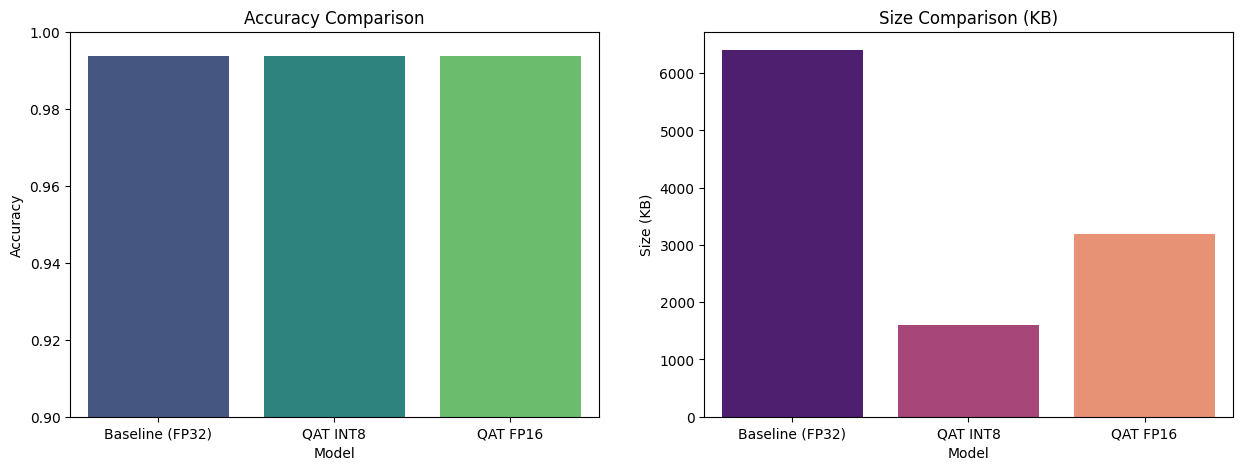

In [11]:
results = [metrics_orig, metrics_int8, metrics_fp16]
temp_path = "temp_model.keras"
model_orig.save(temp_path)
model_sizes = [os.path.getsize(temp_path)/1024, len(tflite_int8)/1024, len(tflite_fp16)/1024]
if os.path.exists(temp_path): os.remove(temp_path)

comp_data = []
for i, res in enumerate(results):
    comp_data.append({
        "Model": res["label"],
        "Size (KB)": f"{model_sizes[i]:.2f}",
        "Compression": f"{model_sizes[0]/model_sizes[i]:.2f}x",
        "Accuracy": f"{res['accuracy']:.4f}",
        "Sensitivity": f"{res['sensitivity']:.4f}",
        "Specificity": f"{res['specificity']:.4f}",
        "F1-Score": f"{res['f1_score']:.4f}",
        "AUC": f"{res['auc_macro']:.4f}",
        "Inf Time (ms)": f"{res['inf_time']*1000:.2f}"
    })

df_comp = pd.DataFrame(comp_data)
display(df_comp)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x="Model", y=df_comp["Accuracy"].astype(float), data=df_comp, ax=axes[0], palette="viridis")
axes[0].set_ylim(0.9, 1.0); axes[0].set_title("Accuracy Comparison")
sns.barplot(x="Model", y=df_comp["Size (KB)"].astype(float), data=df_comp, ax=axes[1], palette="magma")
axes[1].set_title("Size Comparison (KB)")
plt.show()

,Model,Size (KB),Compression,Accuracy,Sensitivity,Specificity,F1-Score,AUC,Feat Ext (ms),SVM Inf (ms),Total (ms)
0,Baseline (FP32),6402.91,1.00x,0.9937,0.9945,0.9977,0.9871,1.0000,6.45,0.02,6.47
1,QAT INT8,1604.55,3.99x,0.9937,0.9959,0.9977,0.9879,1.0000,5.03,0.03,5.06
2,QAT FP16,3188.11,2.01x,0.9937,0.9945,0.9977,0.9871,1.0000,9.48,0.01,9.49


C:\Users\User\AppData\Local\Temp\ipykernel_16264\768320790.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=df_comp["Accuracy"].astype(float), data=df_comp,
C:\Users\User\AppData\Local\Temp\ipykernel_16264\768320790.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=df_comp["Size (KB)"].astype(float), data=df_comp,
C:\Users\User\AppData\Local\Temp\ipykernel_16264\768320790.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=feat_times, data=df_comp, ax=axes[1,0], palette="coolwarm")
C:\Users\User

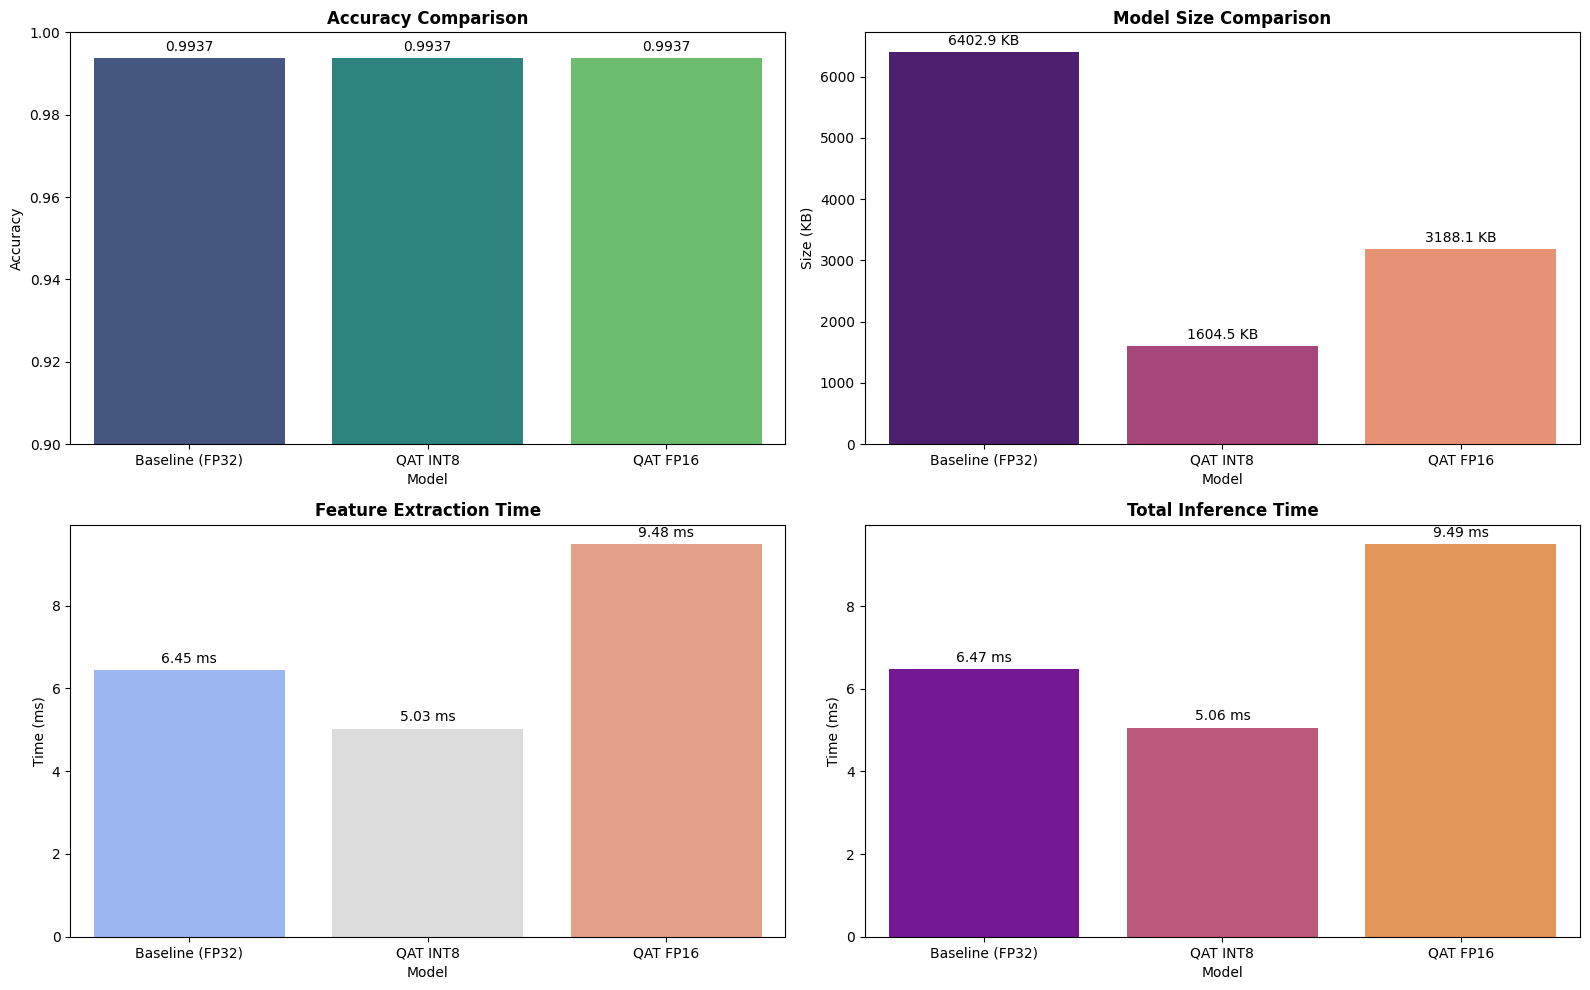

In [12]:
results = [metrics_orig, metrics_int8, metrics_fp16]
temp_path = "temp_model.keras"
model_orig.save(temp_path)
model_sizes = [os.path.getsize(temp_path)/1024, len(tflite_int8)/1024, len(tflite_fp16)/1024]
if os.path.exists(temp_path): os.remove(temp_path)

comp_data = []
for i, res in enumerate(results):
    comp_data.append({
        "Model": res["label"],
        "Size (KB)": f"{model_sizes[i]:.2f}",
        "Compression": f"{model_sizes[0]/model_sizes[i]:.2f}x",
        "Accuracy": f"{res['accuracy']:.4f}",
        "Sensitivity": f"{res['sensitivity']:.4f}",
        "Specificity": f"{res['specificity']:.4f}",
        "F1-Score": f"{res['f1_score']:.4f}",
        "AUC": f"{res['auc_macro']:.4f}",
        "Feat Ext (ms)": f"{res['feat_time']*1000:.2f}",  # ✅ ADDED
        "SVM Inf (ms)": f"{res['inf_time']*1000:.2f}",    # ✅ RENAMED from "Inf Time"
        "Total (ms)": f"{(res['feat_time'] + res['inf_time'])*1000:.2f}"  # ✅ ADDED
    })

df_comp = pd.DataFrame(comp_data)
display(df_comp)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))  # ✅ CHANGED to 2x2 grid

# 1. Accuracy Comparison
sns.barplot(x="Model", y=df_comp["Accuracy"].astype(float), data=df_comp, 
           ax=axes[0,0], palette="viridis")
axes[0,0].set_ylim(0.9, 1.0)
axes[0,0].set_title("Accuracy Comparison", fontsize=12, fontweight='bold')
axes[0,0].set_ylabel("Accuracy")
# Add value labels on bars
for container in axes[0,0].containers:
    axes[0,0].bar_label(container, fmt='%.4f', padding=3)

# 2. Model Size Comparison
sns.barplot(x="Model", y=df_comp["Size (KB)"].astype(float), data=df_comp, 
           ax=axes[0,1], palette="magma")
axes[0,1].set_title("Model Size Comparison", fontsize=12, fontweight='bold')
axes[0,1].set_ylabel("Size (KB)")
# Add value labels
for container in axes[0,1].containers:
    axes[0,1].bar_label(container, fmt='%.1f KB', padding=3)

# 3. Feature Extraction Time Comparison  # ✅ NEW
feat_times = df_comp["Feat Ext (ms)"].astype(float)
sns.barplot(x="Model", y=feat_times, data=df_comp, ax=axes[1,0], palette="coolwarm")
axes[1,0].set_title("Feature Extraction Time", fontsize=12, fontweight='bold')
axes[1,0].set_ylabel("Time (ms)")
# Add value labels
for container in axes[1,0].containers:
    axes[1,0].bar_label(container, fmt='%.2f ms', padding=3)

# 4. Total Inference Time (Feat Ext + SVM)  # ✅ NEW
total_times = df_comp["Total (ms)"].astype(float)
sns.barplot(x="Model", y=total_times, data=df_comp, ax=axes[1,1], palette="plasma")
axes[1,1].set_title("Total Inference Time", fontsize=12, fontweight='bold')
axes[1,1].set_ylabel("Time (ms)")
# Add value labels
for container in axes[1,1].containers:
    axes[1,1].bar_label(container, fmt='%.2f ms', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# SAVE QAT MODELS
# ============================================================================
from datetime import datetime
import shutil

# Create folder
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
save_folder = f"saved_models_qat_{timestamp}"
os.makedirs(save_folder, exist_ok=True)

print(f"\n{'='*70}")
print(f"SAVING TO: {save_folder}")
print(f"{'='*70}\n")

# 1. TFLite models
shutil.copy2(path_int8, os.path.join(save_folder, "extractor_int8.tflite"))
shutil.copy2(path_fp16, os.path.join(save_folder, "extractor_fp16.tflite"))
print("✅ TFLite models saved")

# 2. SVM & Scalers
joblib.dump(svm_int8, os.path.join(save_folder, "svm_int8.pkl"))
joblib.dump(scaler_int8, os.path.join(save_folder, "scaler_int8.pkl"))
joblib.dump(svm_fp16, os.path.join(save_folder, "svm_fp16.pkl"))
joblib.dump(scaler_fp16, os.path.join(save_folder, "scaler_fp16.pkl"))
print("✅ SVM classifiers saved")

# 3. Baseline (reference)
model_orig.save(os.path.join(save_folder, "baseline.keras"))
joblib.dump(svm_orig, os.path.join(save_folder, "svm_baseline.pkl"))
joblib.dump(scaler_orig, os.path.join(save_folder, "scaler_baseline.pkl"))
print("✅ Baseline model saved")

# 4. Metrics
df_comp.to_csv(os.path.join(save_folder, "metrics.csv"), index=False)
print("✅ Metrics saved")

# 5. Plots
plt.savefig(os.path.join(save_folder, "comparison.png"), dpi=150, bbox_inches='tight')
print("✅ Plots saved")

# 6. Summary
temp_baseline_path = "temp_baseline.keras"
model_orig.save(temp_baseline_path)
size_baseline_kb = os.path.getsize(temp_baseline_path) / 1024
os.remove(temp_baseline_path)

summary = {
    "baseline": {"acc": float(metrics_orig["accuracy"]), "size_kb": float(size_baseline_kb)},
    "int8": {"acc": float(metrics_int8["accuracy"]), "size_kb": float(len(tflite_int8) / 1024)},
    "fp16": {"acc": float(metrics_fp16["accuracy"]), "size_kb": float(len(tflite_fp16) / 1024)}
}
with open(os.path.join(save_folder, "summary.json"), 'w') as f:
    json.dump(summary, f, indent=2)
print("✅ Summary saved")

print(f"\n{'='*70}")
print("SAVED FILES:")
print(f"{'='*70}")
for f in sorted(os.listdir(save_folder)):
    size = os.path.getsize(os.path.join(save_folder, f)) / 1024
    print(f"  {f:<30} {size:>10.2f} KB")
print(f"{'='*70}\n")


SAVING TO: saved_models_qat_20260516_134404

✅ TFLite models saved
✅ SVM classifiers saved
✅ Baseline model saved
✅ Metrics saved
✅ Plots saved


NameError: name 'size_baseline_kb' is not defined

<Figure size 640x480 with 0 Axes>